## Assignment 1 (50 marks)
#### =====================================================================================================
### Deadline: 02/12 11:59 pm
#### =====================================================================================================

### Problem 1: SVM Classification (35 marks)

`lab01_dataset_1.xlsx` contains the claim history of 27,513 homeowner policies. The following table describes the eleven columns in the dataset.

| Name | Description |
| --- | --- |
| policy | Policy Identifier |
| exposure | Duration a Policy exposed in a Year |
| num_claims | Number of Claims in a Year |
| amt_claims | Total Claim Amount in a Year	|
| f_primary_age_tier | Age Tier of Primary Insured |
| f_primary_gender | Gender of Primary Insured |
| f_marital | Marital Status of Primary Insured |
| f_residence_location | Location of Residence Property |
| f_fire_alarm_type | Fire Alarm Type |
| f_mile_fire_station | Distance to Nearest Fire Station |
| f_aoi_tier | Amount of Insurance Tier |

We want to predict the *Frequency* which is the *number of claims per unit of exposure* using the above features.  We first divide the reported number of claims by the exposure. This gives us the *Frequency*.  Next, we put the policies into five groups according to their *Frequency* values. We will use this *Group* as our target variable which has five classes.

| Group | Values |
| :--- | :--- |
| 0 | Frequency = 0 |
| 1 | 0 < Frequency <= 1 |
| 2 | 1 < Frequency <= 2 |
| 3 | 2 < Frequency <= 3 |
| 4 | 3 < Frequency |


### 1.a (6 marks)
Create a new column for the dataset which will indiciate the *Frequency Group* and output the updated dataset.

In [10]:
import pandas as pd
import numpy as np

dataset = 'lab01_dataset_1.xlsx'
df = pd.read_excel(dataset)

# create new column 'Frequency'
df['Frequency'] = df['num_claims'] / df['exposure']

Group_Frequency = [
    (df['Frequency'] == 0),
    (df['Frequency'] > 0) & (df['Frequency'] <= 1),
    (df['Frequency'] > 1) & (df['Frequency'] <= 2),
    (df['Frequency'] > 2) & (df['Frequency'] <= 3),
    (df['Frequency'] > 3),
]

Group = [0, 1 ,2, 3, 4]

df['Frequency_Group'] = np.select(Group_Frequency, Group, default=np.nan)

df








,policy,exposure,num_claims,amt_claims,f_primary_age_tier,f_primary_gender,f_marital,f_residence_location,f_fire_alarm_type,f_mile_fire_station,f_aoi_tier,Frequency,Frequency_Group
0,P00001,1.00,0,0.00,21 - 27,Male,Married,Urban,Alarm Service,< 1 mile,351K - 600K,0.0,0.0
1,G00002,1.00,0,0.00,38 - 60,Male,Un-Married,Suburban,NaN,1 - 5 miles,< 100K,0.0,0.0
2,A00003,1.00,2,3079.01,38 - 60,Female,Married,Suburban,Standalone,< 1 mile,100K - 350K,2.0,2.0
3,P00004,1.00,1,804.87,28 - 37,Female,Un-Married,Suburban,Standalone,1 - 5 miles,< 100K,1.0,1.0
4,G00005,1.00,1,638.74,28 - 37,Female,Un-Married,Suburban,Alarm Service,< 1 mile,100K - 350K,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27508,Z27509,1.00,0,0.00,38 - 60,Male,Married,Urban,NaN,< 1 mile,100K - 350K,0.0,0.0
27509,Z27510,1.00,1,1246.57,21 - 27,Male,Married,Urban,Alarm Service,< 1 mile,351K - 600K,1.0,1.0
27510,G27511,1.00,1,18.36,28 - 37,Male,Un-Married,Suburban,Standalone,1 - 5 miles,100K - 350K,1.0,1.0
27511,P27512,0.11,0,0.00,38 - 60,Male,Married,Suburban,Standalone,< 1 mile,100K - 350K,0.0,0.0


### 1.b (6 marks)
There are seven categorial features in the dataset namely, *f_aoi_tier, f_primary_age_tier, f_fire_alarm_type, f_marital, f_mile_fire_station, f_primary_gender, f_residence_location*. Display all the unique values of these seven categories.

In [11]:
categories = [
    'f_aoi_tier', 'f_primary_age_tier', 'f_fire_alarm_type', 
    'f_marital', 'f_mile_fire_station', 'f_primary_gender', 'f_residence_location'
]

for feature in categories:
    values = df[feature].unique()
    print(f"{feature}: {values}\n")


f_aoi_tier: ['351K - 600K' '< 100K' '100K - 350K' '601K - 1M' '> 1M']

f_primary_age_tier: ['21 - 27' '38 - 60' '28 - 37' '> 60' '< 21']

f_fire_alarm_type: ['Alarm Service' nan 'Standalone']

f_marital: ['Married' 'Un-Married' 'Not Married']

f_mile_fire_station: ['< 1 mile' '1 - 5 miles' '> 10 miles' '6 - 10 miles']

f_primary_gender: ['Male' 'Female']

f_residence_location: ['Urban' 'Suburban' 'Rural']



### 1.c (6 marks)
We will train SVM models using those seven categorical features. However, their values are currently all categorical data, but SVM requires them to be numerical. Perform ***one-hot encoding*** on these features to obtain an updated dataset which has only numerical values.

In [12]:
df_one_hot_encoding = pd.get_dummies(df, columns=categories, dtype=int)

df_one_hot_encoding


,policy,exposure,num_claims,amt_claims,Frequency,Frequency_Group,f_aoi_tier_100K - 350K,f_aoi_tier_351K - 600K,f_aoi_tier_601K - 1M,f_aoi_tier_< 100K,...,f_marital_Un-Married,f_mile_fire_station_1 - 5 miles,f_mile_fire_station_6 - 10 miles,f_mile_fire_station_< 1 mile,f_mile_fire_station_> 10 miles,f_primary_gender_Female,f_primary_gender_Male,f_residence_location_Rural,f_residence_location_Suburban,f_residence_location_Urban
0,P00001,1.00,0,0.00,0.0,0.0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1
1,G00002,1.00,0,0.00,0.0,0.0,0,0,0,1,...,1,1,0,0,0,0,1,0,1,0
2,A00003,1.00,2,3079.01,2.0,2.0,1,0,0,0,...,0,0,0,1,0,1,0,0,1,0
3,P00004,1.00,1,804.87,1.0,1.0,0,0,0,1,...,1,1,0,0,0,1,0,0,1,0
4,G00005,1.00,1,638.74,1.0,1.0,1,0,0,0,...,1,0,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27508,Z27509,1.00,0,0.00,0.0,0.0,1,0,0,0,...,0,0,0,1,0,0,1,0,0,1
27509,Z27510,1.00,1,1246.57,1.0,1.0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1
27510,G27511,1.00,1,18.36,1.0,1.0,1,0,0,0,...,1,1,0,0,0,0,1,0,1,0
27511,P27512,0.11,0,0.00,0.0,0.0,1,0,0,0,...,0,0,0,1,0,0,1,0,1,0


### 1.d (6 marks)
Divide the observations into training and testing partitions. Observations whose *Policy Identifier* starts with the letters A, G, and P will go to the training partition. The remaining observations go to the testing partition. Output the total number of policies present in the Training partition and Testing partition.

In [13]:
# 'A', 'G', 'P' for training
# only true or false for every policy
filtered_training = df_one_hot_encoding['policy'].str.startswith(('A', 'G', 'P'))
# keeping only the rows with A, G, P with their values
training_data = df_one_hot_encoding[filtered_training]

# Select all other policies for testing data
filtered_testing = ~filtered_training  # Invert the mask to get the remaining rows
testing_data = df_one_hot_encoding[filtered_testing]

num_training_data = len(training_data)
num_testing_data = len(testing_data)

print(f"Partition of training data: {num_training_data}")
print(f"Partition of testing data: {num_testing_data}")





Partition of training data: 20661
Partition of testing data: 6852


### 1.e (6 marks)
Train an SVM model using [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html). The input features will be the encoded version of the feature set *f_aoi_tier, f_primary_age_tier, f_fire_alarm_type, f_marital, f_mile_fire_station, f_primary_gender, f_residence_location* and the output is the *Frequency Group*. Use `verbose=1` to observe the optimization steps during the training process.

In [26]:
from sklearn.svm import LinearSVR
from sklearn.model_selection import train_test_split

X_train = training_data.drop(['policy', 'exposure', 'num_claims', 'amt_claims', 'Frequency', 'Frequency_Group'], axis=1)
y_train = training_data['Frequency_Group']
X_test = testing_data.drop(['policy', 'exposure', 'num_claims', 'amt_claims', 'Frequency', 'Frequency_Group'], axis=1)
y_test = testing_data['Frequency_Group']

svm_model = LinearSVR(verbose=1)
svm_model.fit(X_train, y_train)

[LibLinear]....*
optimization finished, #iter = 49
Objective value = -15511.407101
nSV = 20661


LinearSVR(verbose=1)

### 1.f (5 marks)
Compute and output the Accuracy Score on the Testing partition.

In [17]:
from sklearn.metrics import accuracy_score

y_pred = np.round(svm_model.predict(X_test))

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.5309398715703444

### Problem 2: Perceptron Learning (15 marks)

The dataset `lab01_dataset_2.csv` has a *3-dimensional input space* and a class label of *Positive* and *Negative*. For this task, you are **not allowed** to use any *functionalities* of the `sklearn` module.

### 2.a (10 marks)
Write a function `my_perceptron()` which applies the perceptron algorithm (refer to the lecture slide covering linear separators for details of this algorithm) on the dataset to create a linear separator. `my_perceptron()` takes the dataset as its input and returns a ***3-dimensional weight vector*** which can be used to create the linear separator (assume `bias = 0`). Use the *initial weights* `w = [1,2,3]`. Use a classification threshold of `99%` i.e., `my_perceptron()` will terminate once the misclassification rate is less than `1%`.

In [5]:
import pandas as pd
data_pd = pd.read_csv('lab01_dataset_2.csv')

data_np = data_pd.to_numpy()

w = [1.0, 2.0, 3.0]
threshold = 0.01
iteration_number = 1000
learning_rate = 1

print(data_pd)
print(type(data_np[0][3]))

            X         Y         Z     Class
0   -2.153269 -1.910092 -2.089200  Negative
1    3.354634 -1.803199 -2.849789  Negative
2   -2.773528  4.644997  2.412375  Positive
3    2.890608 -1.188494 -1.723388  Negative
4   -3.416683  4.789795  3.157649  Positive
..        ...       ...       ...       ...
195  3.894159  4.064941  1.584089  Positive
196 -4.067620  2.598132 -0.450343  Positive
197  2.977411 -2.586627 -1.177683  Negative
198  2.982052  1.579528  0.127011  Positive
199  1.733379  3.304566 -0.442882  Positive

[200 rows x 4 columns]
<class 'str'>


In [7]:
def my_perceptron(data):
    
    
    for i in range(iteration_number):
        misclassification = 0
        for j in range(len(data)):
            pred = w[0]*data[i][0] + w[1]*data[i][1] + w[2]*data[i][2]
            
            if data[i][3] == "Negative":
                y = -1
            else:
                y = 1
                
            if y * pred < 0:
                w[0] += learning_rate * y * data[i][0]
                w[1] += learning_rate * y * data[i][1]
                w[2] += learning_rate * y * data[i][2]
                misclassification += 1
                
        misclassification_rate = misclassification / len(data)
        if misclassification_rate < threshold:
            print(f"Iteration times: {iteration}")
            print(f"Misclassification rate: {misclassification_rate*100:.2f}%")
            break
            
    return w

my_perceptron(data_np)
print(w)

Iteration times: 1
Misclassification rate: 0.00%
[-0.6536302662703912, 5.554343899802061, 2.221430485441772]


### 2.b (5 marks)
Create a *3D plot* which showcases the dataset in a 3D-space alongwith the *linear separator* you obtained from `my_perceptron()`. Use two different colors to represent the data points belonging in the two classes for ease of viewing.

In [10]:
import matplotlib.pyplot as plt 
import numpy as np
from mpl_toolkits import mplot3d

def plot_3D(data):
    ax = plt.axes(projection="3d")

    for i in range(len(data)):
        y_hat = w[0]*data[i][0] + w[1]*data[i][1] + w[2]*data[i][2]
        if y_hat >= 0:
            ax.scatter(data[i][0], data[i][1], data[i][2], color='red')
        else:
            ax.scatter(data[i][0], data[i][1], data[i][2], color='blue')
    
    x1_range = np.linspace(min(data_np[:, 0]), max(data_np[:, 0]), 10)
    x2_range = np.linspace(min(data_np[:, 1]), max(data_np[:, 1]), 10)
    x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
    x3_grid = - (w[0] * x1_grid + w[1] * x2_grid) / w[2]
    ax.plot_surface(x1_grid, x2_grid, x3_grid, color='yellow', alpha=0.5)

    plt.title('Linear Separator')
    plt.show()
    



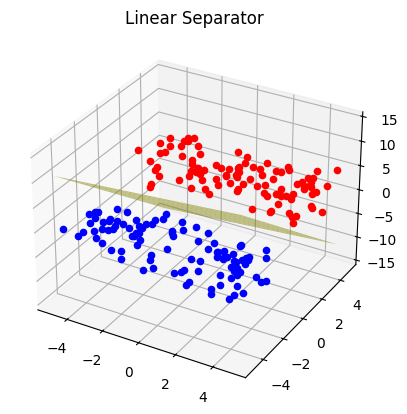

In [11]:
plot_3D(data_np)